In [58]:
# data manipulation
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# random forrest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# google drive access
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
# load first N lines from the dataset

N = 100000
data = pd.read_csv('/content/dataset/Tuesday-WorkingHours.csv', nrows=N)

# check head
data.head(10)


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-192.168.10.3-49159-445-6,192.168.10.5,49159,192.168.10.3,445,6,04/07/2017 01:53:44 PM,90030854,10,10,...,20,2.276133e+04,3.931813e+04,68162.0,57.0,2.998751e+07,3.559250e+04,30013373.0,29946916.0,BENIGN
1,8.6.0.1-8.0.6.4-0-0-0,8.6.0.1,0,8.0.6.4,0,0,04/07/2017 01:54:12 PM,106007973,26,0,...,0,1.730944e+06,2.273625e+06,4789258.0,19.0,1.981684e+07,8.154881e+06,27220170.0,7234941.0,BENIGN
2,192.168.10.5-192.168.10.3-123-123-17,192.168.10.5,123,192.168.10.3,123,17,04/07/2017 01:54:32 PM,64015367,4,4,...,8,1.390000e+02,0.000000e+00,139.0,139.0,6.401513e+07,0.000000e+00,64015127.0,64015127.0,BENIGN
3,192.168.10.3-192.168.10.1-60280-53-17,192.168.10.3,60280,192.168.10.1,53,17,04/07/2017 01:55:07 PM,46870,1,1,...,8,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,BENIGN
4,192.168.10.3-192.168.10.1-61995-53-17,192.168.10.3,61995,192.168.10.1,53,17,04/07/2017 01:54:12 PM,62958,1,1,...,8,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,BENIGN
5,192.168.10.5-192.168.10.3-49159-445-6,192.168.10.5,49159,192.168.10.3,445,6,04/07/2017 01:55:44 PM,61385684,57,56,...,20,3.001600e+04,4.234580e+04,59959.0,73.0,2.997533e+07,4.153050e+04,30004697.0,29945964.0,BENIGN
6,192.168.10.5-192.168.10.3-49159-445-6,192.168.10.5,49159,192.168.10.3,445,6,04/07/2017 01:58:02 PM,66,4,2,...,20,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,BENIGN
7,192.168.10.50-224.0.0.251-5353-5353-17,192.168.10.50,5353,224.0.0.251,5353,17,04/07/2017 01:54:17 PM,12,9,0,...,8,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,BENIGN
8,192.168.10.5-192.168.10.3-49182-88-6,192.168.10.5,49182,192.168.10.3,88,6,04/07/2017 01:54:10 PM,704,8,8,...,20,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,BENIGN
9,192.168.10.5-192.168.10.3-49183-88-6,192.168.10.5,49183,192.168.10.3,88,6,04/07/2017 01:54:10 PM,981,10,8,...,20,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,BENIGN


In [61]:
# check datatypes for columns

num_cols = len(data.columns)
print(f'Number of columns: {num_cols}')

for c in data.columns:
  print(f"{c} => {data[c].dtype}")

Number of columns: 84
Flow ID => object
Src IP => object
Src Port => int64
Dst IP => object
Dst Port => int64
Protocol => int64
Timestamp => object
Flow Duration => int64
Total Fwd Packet => int64
Total Bwd packets => int64
Total Length of Fwd Packet => float64
Total Length of Bwd Packet => float64
Fwd Packet Length Max => float64
Fwd Packet Length Min => float64
Fwd Packet Length Mean => float64
Fwd Packet Length Std => float64
Bwd Packet Length Max => float64
Bwd Packet Length Min => float64
Bwd Packet Length Mean => float64
Bwd Packet Length Std => float64
Flow Bytes/s => float64
Flow Packets/s => float64
Flow IAT Mean => float64
Flow IAT Std => float64
Flow IAT Max => float64
Flow IAT Min => float64
Fwd IAT Total => float64
Fwd IAT Mean => float64
Fwd IAT Std => float64
Fwd IAT Max => float64
Fwd IAT Min => float64
Bwd IAT Total => float64
Bwd IAT Mean => float64
Bwd IAT Std => float64
Bwd IAT Max => float64
Bwd IAT Min => float64
Fwd PSH Flags => int64
Bwd PSH Flags => int64
Fwd U

In [62]:
# preprocess data -> remove Flow ID, IPs and Timestamp, encode Label

data = data.drop(columns=['Flow ID', 'Src IP', 'Dst IP', 'Timestamp'])

le = LabelEncoder()
data['Label Enc'] = le.fit_transform(data['Label'])

data.head(10)

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label Enc
0,49159,445,6,90030854,10,10,8.0,2.0,1.0,0.0,...,2.276133e+04,3.931813e+04,68162.0,57.0,2.998751e+07,3.559250e+04,30013373.0,29946916.0,BENIGN,0
1,0,0,0,106007973,26,0,0.0,0.0,0.0,0.0,...,1.730944e+06,2.273625e+06,4789258.0,19.0,1.981684e+07,8.154881e+06,27220170.0,7234941.0,BENIGN,0
2,123,123,17,64015367,4,4,192.0,192.0,48.0,48.0,...,1.390000e+02,0.000000e+00,139.0,139.0,6.401513e+07,0.000000e+00,64015127.0,64015127.0,BENIGN,0
3,60280,53,17,46870,1,1,44.0,240.0,44.0,44.0,...,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,BENIGN,0
4,61995,53,17,62958,1,1,48.0,80.0,48.0,48.0,...,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,BENIGN,0
5,49159,445,6,61385684,57,56,13950.0,9394.0,2995.0,0.0,...,3.001600e+04,4.234580e+04,59959.0,73.0,2.997533e+07,4.153050e+04,30004697.0,29945964.0,BENIGN,0
6,49159,445,6,66,4,2,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,BENIGN,0
7,5353,5353,17,12,9,0,405.0,0.0,45.0,45.0,...,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,BENIGN,0
8,49182,88,6,704,8,8,440.0,358.0,220.0,0.0,...,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,BENIGN,0
9,49183,88,6,981,10,8,600.0,2944.0,300.0,0.0,...,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,BENIGN,0


In [64]:
# verify Label values

print(data['Label'].unique())
print(data['Label Enc'].unique())

['BENIGN' 'FTP-Patator' 'SSH-Patator']
[0 1 2]


In [65]:
# drop Label for simplicity

data.drop(columns=['Label'], inplace=True)

In [70]:
# drop infinite values cause turns out there are some
data = data[np.isfinite(data).all(axis=1)]
data.head(10)
print(len(data.columns))

80


In [71]:
# generate train and test sets

from sklearn.model_selection import train_test_split

y = data['Label Enc']
X = data.drop(columns=['Label Enc'])

# kind of random values, feel free to modify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
model = RandomForestClassifier(n_estimators=1000, max_features="sqrt", random_state=42, max_samples=100, oob_score=True)
rf = model.fit(X_train, y_train)

In [77]:
# print how well the model generalizes
print(f"OOB Score: {rf.oob_score_}")


OOB Score: 0.9998624707750396


Total Length of Fwd Packet    0.148990
Bwd Packet Length Mean        0.123408
Active Min                    0.105219
Bwd Segment Size Avg          0.105219
Bwd IAT Min                   0.101010
Subflow Bwd Bytes             0.101010
Fwd Packet Length Max         0.101010
Src Port                      0.084175
Average Packet Size           0.064815
Subflow Fwd Bytes             0.023990
dtype: float64


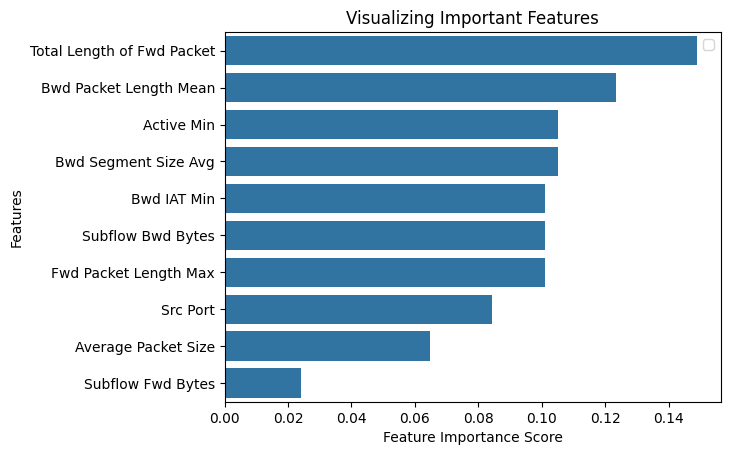

In [84]:
# find important features -> needs better visualization
top_feats = pd.Series(data=rf.feature_importances_, index=X_train.columns)
top_feats.sort_values(ascending=False, inplace=True)
print(top_feats.head(10))

# generate plot
sns.barplot(x=top_feats.head(10).values, y=top_feats.head(10).index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features")
plt.legend()
plt.show()

In [86]:
# evaluate performance

pred_label = rf.predict(X_test)

mae = mean_absolute_error(y_true=y_test, y_pred=pred_label)
mse = mean_squared_error(y_true=y_test, y_pred=pred_label)

print(f"MAE: {mae}")
print(f"MSE: {mse}")

MAE: 0.0007001400280056011
MSE: 0.001200240048009602


[Notes]:

1. There was not much reasoning in the specific values picked for training the model, just wanted to experiment, see if anything would run w/o errors.

2. The accuracy is so high that for sure the model must be overfitting -> maybe we should try on the full dataset -> idk

3. I think training the model and verifying its performance we'll take care of easily -> idk how to compile it to work "outside", i.e. how to integrate it into an app and parse a real PCAP, so it can analyze it

